# Notebook 1 — BiomedCLIP Zero-Shot Classifier
Uses Microsoft's BiomedCLIP (trained on PubMed + MIMIC) to classify chest X-rays
into 6 conditions via zero-shot text-image similarity.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import open_clip
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from pathlib import Path

from config import BIOMED_CLIP_MODEL, CONDITION_PROMPTS, CONDITIONS, CONFIDENCE_THRESHOLD

print(f'PyTorch: {torch.__version__}')
print(f'Device : {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch: 2.11.0
Device : cpu


## 1. Load BiomedCLIP

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model, preprocess, _ = open_clip.create_model_and_transforms(BIOMED_CLIP_MODEL)
tokenizer = open_clip.get_tokenizer(BIOMED_CLIP_MODEL)
model = model.to(device).eval()

print('BiomedCLIP loaded.')
print(f'Conditions: {CONDITIONS}')

BiomedCLIP loaded.
Conditions: ['pneumonia', 'pleural effusion', 'cardiomegaly', 'atelectasis', 'pneumothorax', 'no finding']


## 2. Pre-encode condition text prompts

In [3]:
prompts = list(CONDITION_PROMPTS.values())
tokens = tokenizer(prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

print(f'Text feature matrix: {text_features.shape}  (conditions × embedding_dim)')
print('\nPrompts used:')
for cond, prompt in CONDITION_PROMPTS.items():
    print(f'  {cond:<22} → {prompt}')

Text feature matrix: torch.Size([6, 512])  (conditions × embedding_dim)

Prompts used:
  pneumonia              → chest x-ray showing pneumonia with lung consolidation and opacity
  pleural effusion       → chest x-ray showing pleural effusion with fluid accumulation
  cardiomegaly           → chest x-ray showing cardiomegaly with enlarged heart
  atelectasis            → chest x-ray showing atelectasis with partial lung collapse
  pneumothorax           → chest x-ray showing pneumothorax with collapsed lung and air in pleural space
  no finding             → normal chest x-ray with no significant abnormalities


## 3. Classification helper

In [4]:
def classify(image: Image.Image) -> dict:
    img_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(img_tensor)
        image_features /= image_features.norm(dim=-1, keepdim=True)
    logits = (image_features @ text_features.T).squeeze(0)
    probs = torch.softmax(logits * 100, dim=0).cpu().numpy()
    scores = {c: float(p) for c, p in zip(CONDITIONS, probs)}
    top = max(scores, key=scores.get)
    return {'scores': scores, 'top': top, 'top_score': scores[top],
            'low_confidence': scores[top] < CONFIDENCE_THRESHOLD}

def plot_scores(image: Image.Image, result: dict, title: str = ''):
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
    ax_img.imshow(image, cmap='gray')
    ax_img.set_title(title or 'Input X-ray', fontsize=11)
    ax_img.axis('off')

    conditions = list(result['scores'].keys())
    scores = [result['scores'][c] for c in conditions]
    colors = ['#e74c3c' if c == result['top'] else '#3498db' for c in conditions]
    bars = ax_bar.barh(conditions, scores, color=colors)
    ax_bar.set_xlim(0, 1)
    ax_bar.axvline(CONFIDENCE_THRESHOLD, color='gray', linestyle='--', alpha=0.6, label=f'Threshold ({CONFIDENCE_THRESHOLD})')
    for bar, val in zip(bars, scores):
        ax_bar.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)
    ax_bar.set_xlabel('Probability')
    ax_bar.set_title(f'Prediction: {result["top"]} ({result["top_score"]:.1%})', fontsize=11)
    ax_bar.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 4. Classify all eval images

In [5]:
import csv

eval_dir = Path('../data/eval')
labels_csv = eval_dir / 'labels.csv'

with open(labels_csv, encoding='utf-8') as f:
    samples = list(csv.DictReader(f))

print(f'Found {len(samples)} labeled images')
for s in samples:
    print(f'  {s["filename"]:<35} true={s["label"]}')

Found 7 labeled images
  eval_normal_01.jpg                  true=no finding
  eval_pneumonia_01.jpg               true=pneumonia
  eval_pneumothorax_01.jpg            true=pneumothorax
  eval_atelectasis_01.jpg             true=atelectasis
  eval_pleural_effusion_01.jpg        true=pleural effusion
  eval_normal_02.png                  true=no finding
  eval_cardiomegaly_01.jpg            true=cardiomegaly


In [6]:
results = []
for sample in samples:
    img_path = eval_dir / sample['filename']
    image = Image.open(img_path).convert('RGB')
    result = classify(image)
    correct = result['top'] == sample['label']
    results.append({**sample, **result, 'correct': correct, 'image': image})
    marker = '✓' if correct else '✗'
    print(f'{marker}  {sample["filename"]:<35}  true={sample["label"]:<20}  pred={result["top"]:<20}  ({result["top_score"]:.1%})')

✓  eval_normal_01.jpg                   true=no finding            pred=no finding            (100.0%)


✗  eval_pneumonia_01.jpg                true=pneumonia             pred=pleural effusion      (99.7%)


✗  eval_pneumothorax_01.jpg             true=pneumothorax          pred=no finding            (55.2%)


✓  eval_atelectasis_01.jpg              true=atelectasis           pred=atelectasis           (98.7%)


✗  eval_pleural_effusion_01.jpg         true=pleural effusion      pred=pneumothorax          (73.5%)


✗  eval_normal_02.png                   true=no finding            pred=cardiomegaly          (90.5%)


✓  eval_cardiomegaly_01.jpg             true=cardiomegaly          pred=cardiomegaly          (95.6%)


## 5. Visualize each prediction

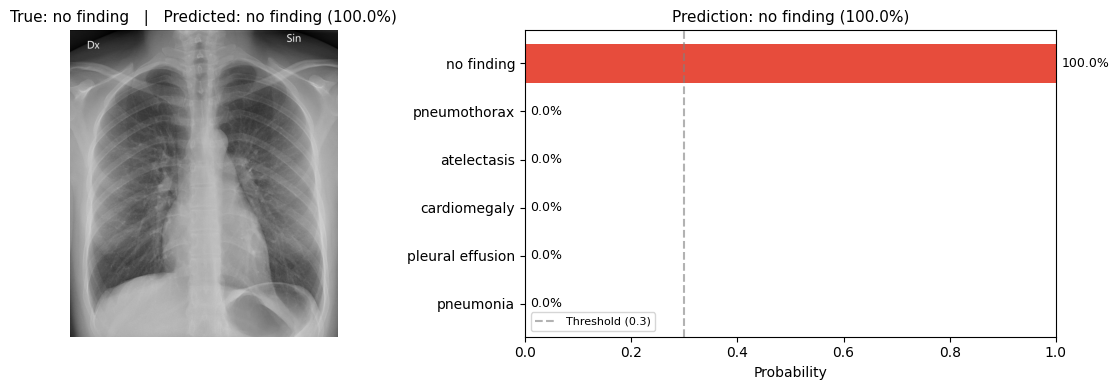

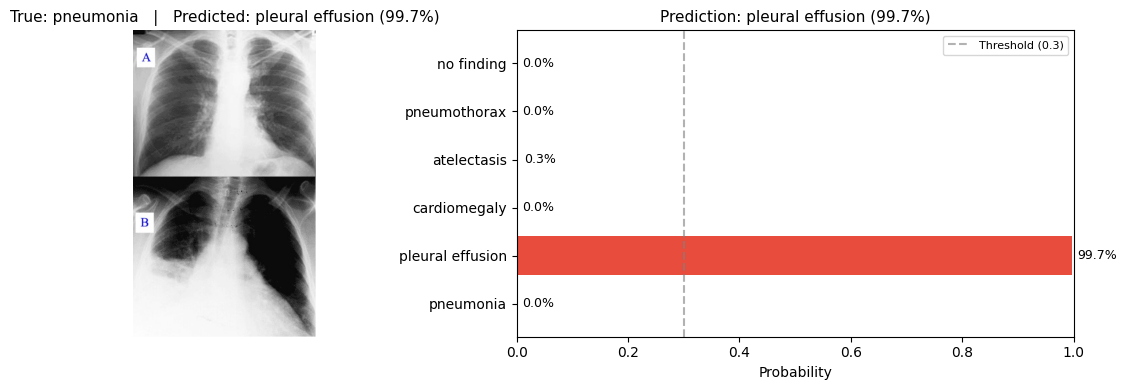

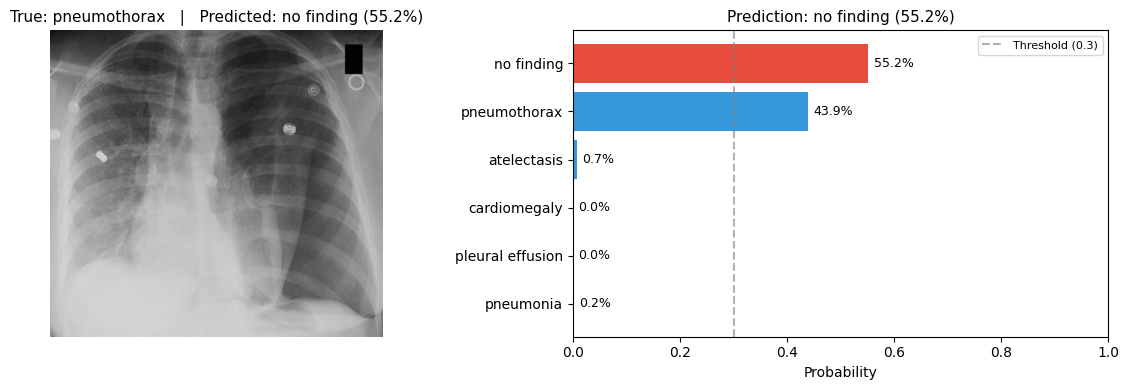

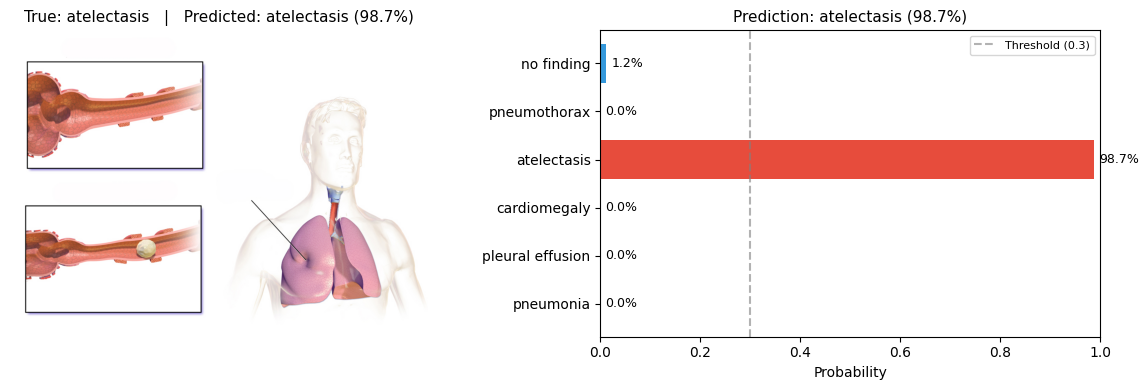

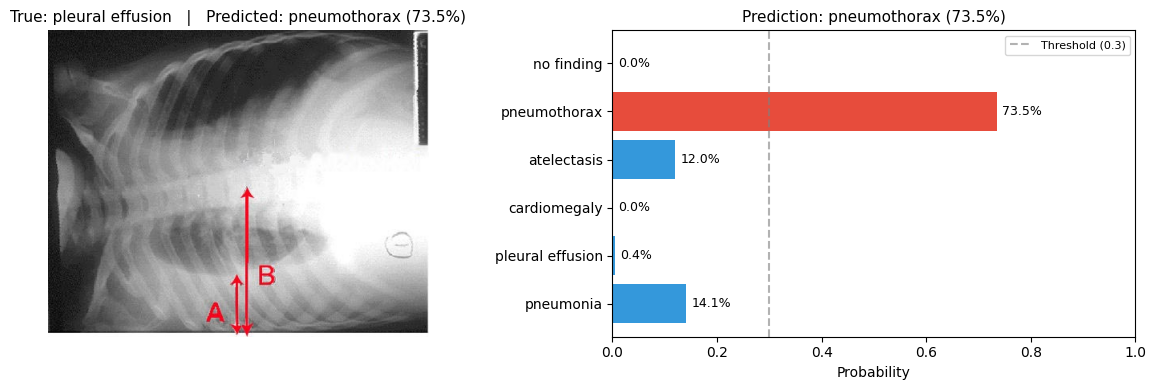

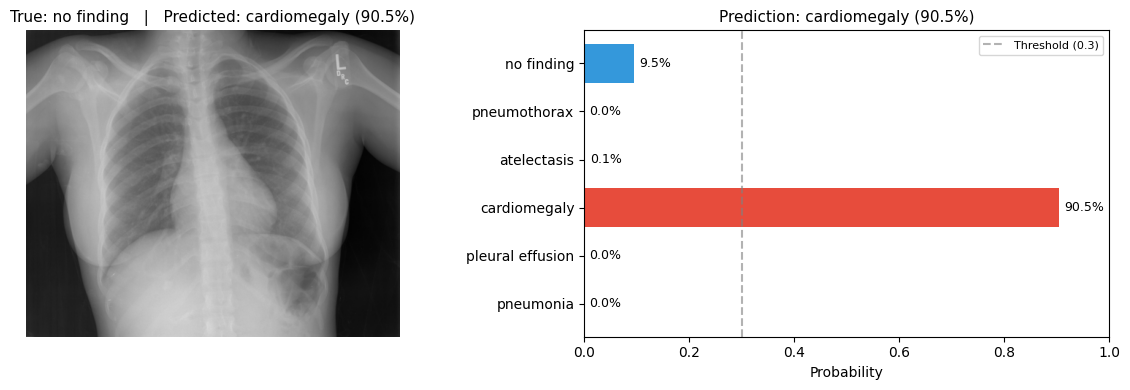

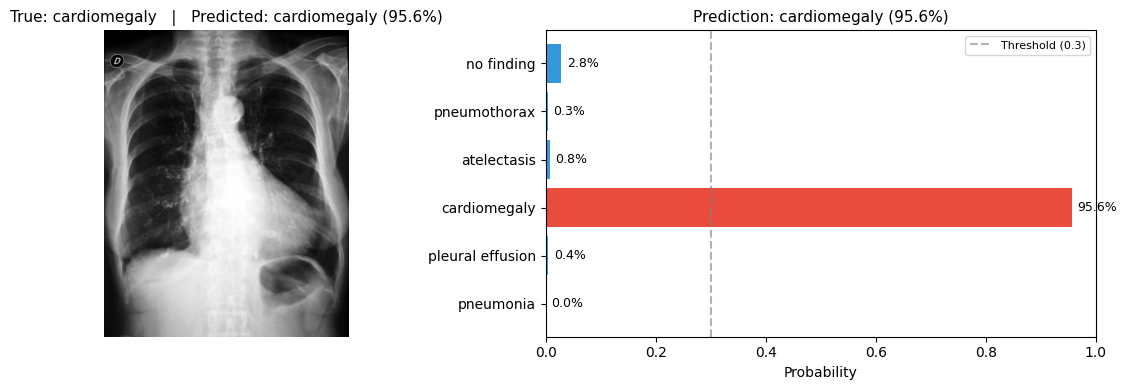

In [7]:
for r in results:
    title = f'True: {r["label"]}   |   Predicted: {r["top"]} ({r["top_score"]:.1%})'
    plot_scores(r['image'], r, title=title)

## 6. Summary

In [8]:
n = len(results)
correct = sum(r['correct'] for r in results)
top2_correct = sum(
    1 for r in results
    if r['label'] in sorted(r['scores'], key=r['scores'].get, reverse=True)[:2]
)

print(f'Total images  : {n}')
print(f'Top-1 Accuracy: {correct}/{n}  ({correct/n:.1%})')
print(f'Top-2 Accuracy: {top2_correct}/{n}  ({top2_correct/n:.1%})')
print()
print('Per-image:')
for r in results:
    mark = '✓' if r['correct'] else '✗'
    print(f'  {mark}  {r["label"]:<20} → {r["top"]:<20} ({r["top_score"]:.1%})')

Total images  : 7
Top-1 Accuracy: 3/7  (42.9%)
Top-2 Accuracy: 5/7  (71.4%)

Per-image:
  ✓  no finding           → no finding           (100.0%)
  ✗  pneumonia            → pleural effusion     (99.7%)
  ✗  pneumothorax         → no finding           (55.2%)
  ✓  atelectasis          → atelectasis          (98.7%)
  ✗  pleural effusion     → pneumothorax         (73.5%)
  ✗  no finding           → cardiomegaly         (90.5%)
  ✓  cardiomegaly         → cardiomegaly         (95.6%)
